
# AI Programming with Python Final Exam

**Name: Your Name**

**Course Email:**  startrack613@gmail.com


## End of Assignment

Before submitting:
- Must watch the Exam Instructions Video
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# 0) Starter Code (Run First)

In [71]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

# Question 01: [ Marks 10 ]

Use NumPy arrays from the score and attendance columns. Print both arrays and display:

* Data type
* Number of dimensions
* Shape
* Total number of elements

# Write Answer 01:


In [72]:
df=np.genfromtxt('school_data.csv',delimiter=',',skip_header=True)
score=df[:,2]
print(score.dtype)
print(score.ndim)
print(score.shape)
print(score.size)

attendance=df[:,3]
print(attendance.dtype)
print(attendance.ndim)
print(attendance.shape)
print(attendance.size)


float64
1
(50,)
50
float64
1
(50,)
50


# Question 02: [ Marks 10 ]

## Using NumPy functions on :

* Find the maximum and minimum score
* Calculate the average score
* Calculate the average attendance

Then, extract students who:

* Have a score greater than the average score

Print:

* The filtered score array

## Write Answer 02:


In [73]:
mn=np.min(score)
mx=np.max(score)
avg=np.mean(score)
avg_att=np.mean(attendance)
print(mn,mx,avg, avg_att)
ex=df[score>avg]
print(ex[:,0])

41.0 99.0 67.3 79.58
[201. 202. 206. 210. 212. 213. 216. 220. 221. 223. 225. 226. 229. 230.
 231. 235. 236. 238. 239. 242. 243. 245. 247. 248.]


# Question 03: [Marks 10]

##
Load the school_data.csv file into a Pandas DataFrame.

* Display the first 3 rows
* Show dataset information using .info()
* Display summary statistics using .describe()

Then filter the dataset to include only:

* student_id, student_age, department, grade

Select students whose age is between 16 and 20, sort them by student_id, and display the last 3 rows of the result.


## Write Answer 03:

In [74]:
df=pd.DataFrame(pd.read_csv('school_data.csv'))
print(df.head(3))
print(df.info())
print(df.describe())
filter=df[['student_id','student_age','department','grade']]
filter=filter.loc[(filter['student_age']>=16) & (filter['student_age']<=20)].sort_values('student_id')
print(filter.tail(3))

   student_id  student_age  score  attendance department grade
0         201           21     76          73    Physics     B
1         202           18     90          82    Physics     A
2         203           19     46          99    Biology     F
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   50 non-null     int64 
 1   student_age  50 non-null     int64 
 2   score        50 non-null     int64 
 3   attendance   50 non-null     int64 
 4   department   50 non-null     object
 5   grade        50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None
       student_id  student_age      score  attendance
count    50.00000    50.000000  50.000000   50.000000
mean    225.50000    18.280000  67.300000   79.580000
std      14.57738     1.852081  18.248008   12.163998
min     201.00000    15.000000  41.000000   60.


# Question 04: [ Marks 10 ]

##
Using .loc:

* Increase the score by 10% for students in "Computer Science" and "Mathematics" departments
* Increase the score by 5% for all other departments
* Cap the score at 100 (no score should exceed 100 after the raise)

Then print a DataFrame that includes:

* student_id, department, previous_score, new_score, score_increase


## Write Answer 04:

In [75]:
con=(df['department']=='Computer Science')|(df['department']=='Mathematics')
filter=df.copy()
filter.loc[con,'score']=df.loc[con,'score']*1.1
filter.loc[~con,'score']=df.loc[~con,'score']*1.05
filter.loc[filter['score']>100,'score']=filter.loc[filter['score']>100,'score']=100

filter.rename(columns={'score':'new_score'},inplace=True)
filter['previous_score']=df['score']
filter['score_increase']=filter['new_score']-filter['previous_score']
filter.drop(['student_age','attendance','grade'],axis=1,inplace=True)
filter.head()

/tmp/ipykernel_431/2012132507.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 70.4 108.9  58.3  52.8 108.9  91.3  47.3  74.8  77. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  filter.loc[con,'score']=df.loc[con,'score']*1.1


,student_id,new_score,department,previous_score,score_increase
0,201,79.8,Physics,76,3.8
1,202,94.5,Physics,90,4.5
2,203,48.3,Biology,46,2.3
3,204,63.0,Economics,60,3.0
4,205,50.4,Economics,48,2.4


# Question 05: [ Marks 10 ]

Using Matplotlib, create a bar chart that shows the average score per department.

* X-axis: Department names
* Y-axis: Average score
* Add a title: "Average Score by Department"
* Display the chart

## Answer 05:

         department      score
0              Arts  70.000000
1           Biology  70.125000
2         Chemistry  63.666667
3          Commerce  59.000000
4  Computer Science  67.833333
5         Economics  58.666667
6           English  54.250000
7       Mathematics  73.333333
8           Physics  78.444444
9           Science  62.000000


Text(0.5, 1.0, 'Average Score by Department')

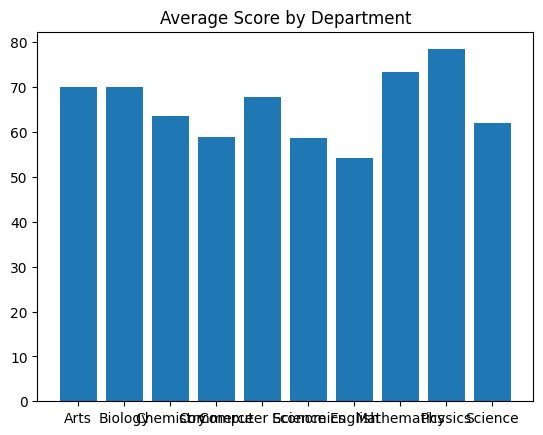

In [84]:
dept_group=df.groupby('department')['score'].mean().reset_index()
print(dept_group)

plt.bar(dept_group['department'],dept_group['score'])
plt.title('Average Score by Department')


# Question 06: [ Marks 10 ]

Using Matplotlib, create a histogram of the score column.

* Use 10 bins
* Add a title: "Distribution of Student Scores"
* Label X-axis as "Score" and Y-axis as "Number of Students"
* Display the chart

## Answer 06:

Text(0, 0.5, 'Number of Students')

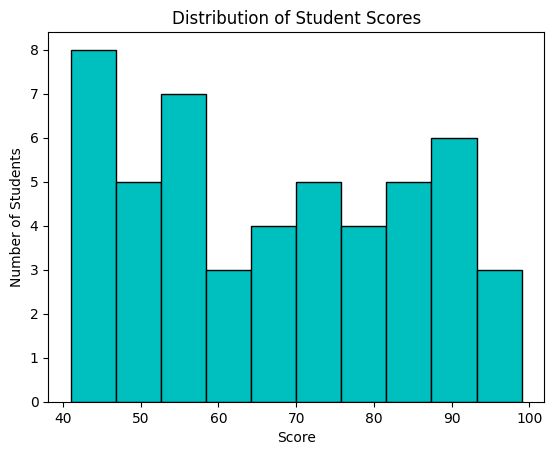

In [85]:
plt.hist(df['score'], bins=10, color='c', edgecolor='k')
plt.title('Distribution of Student Scores')
plt.xlabel('Score')
plt.ylabel('Number of Students')

# Question 07: [ Marks 10 ]

Using Matplotlib, create a scatter plot to visualize the relationship between attendance and score.

* X-axis: Attendance (%)
* Y-axis: Score
* Add a title: "Attendance vs Score"
* Label both axes properly
* Display the chart

## Answer 07:


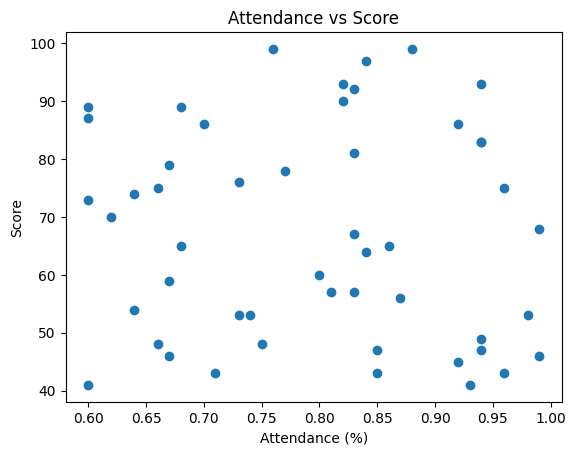

In [88]:
plt.xlabel('Attendance (%)')
plt.ylabel('Score')
plt.title('Attendance vs Score')
plt.scatter(df['attendance']*.01, df['score'])

# Question 08: [ Marks 10 ]

Using Seaborn, create a boxplot / barplot that shows the distribution of score across different grade categories.

* X-axis: Grade
* Y-axis: Score
* Add a title: "Score Distribution by Grade"
* Display the chart

## Answer 08:

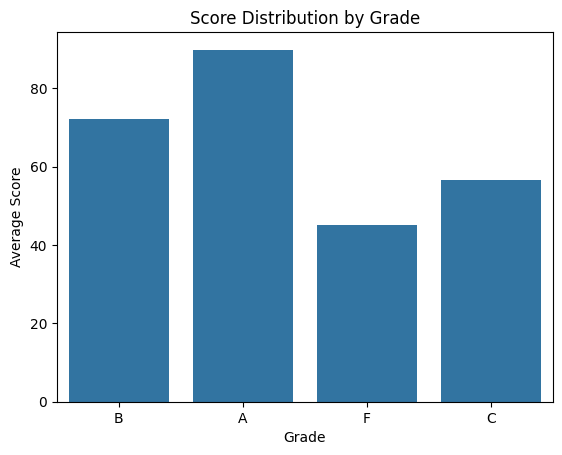

In [91]:
sns.barplot(data=df, x='grade', y='score',errorbar=None)
plt.title("Score Distribution by Grade")
plt.xlabel("Grade")
plt.ylabel("Average Score")

plt.show()

# Question 09: [ Marks 10 ]

Using Seaborn, create a countplot showing the number of students in each department.

* Add a title: "Number of Students per Department"
* Display the chart

# Write Answer 09:

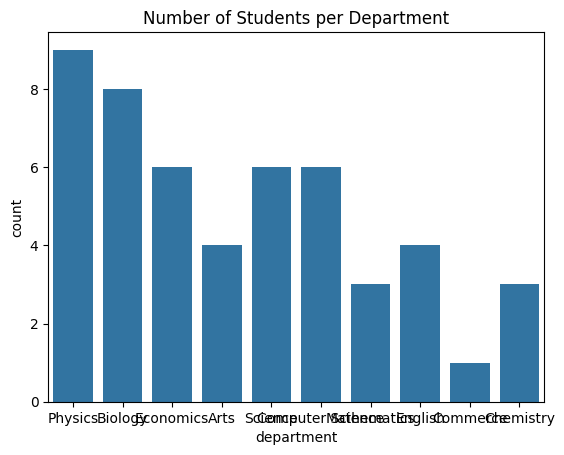

In [92]:
sns.countplot(data=df, x='department')
plt.title("Number of Students per Department")

plt.show()

# Question 10: [ Marks 10 ]

create a scatter plot showing attendance vs score.

* Color the points by department
* Add a title: "Attendance vs Score by Department"
* Label X-axis as "Attendance (%)" and Y-axis as "Score"
* Display the chart

# Write Answer 10:

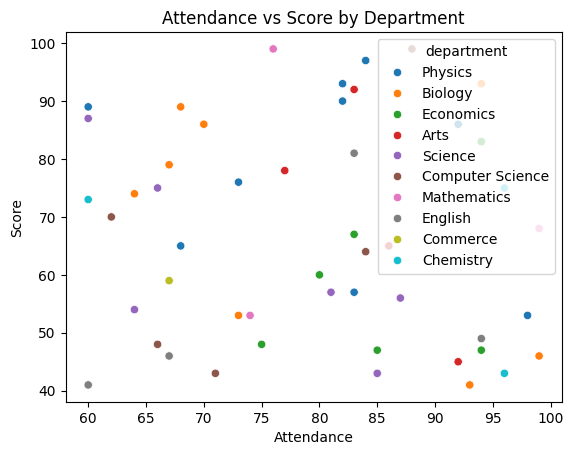

In [95]:
sns.scatterplot(data=df, x='attendance', y='score',hue='department')
plt.title("Attendance vs Score by Department")
plt.xlabel("Attendance")
plt.ylabel("Score")

plt.show()